In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/q1_heart_disease.csv")
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Interpretation:

The dataset contains patient health-related information such as age, sex, blood pressure, cholesterol levels, and heart rate, along with medical indicators like chest pain type and ECG results. The target variable `heart_disease` indicates whether the patient has heart disease (1) or not (0).

From the first few rows, we can observe that the dataset includes both numerical and categorical features. For example, variables like age, resting_bp, and cholesterol are numerical, while chest_pain_type and resting_ecg are categorical.

The sample data also shows variation across patients in terms of age, medical conditions, and heart disease status, which suggests that these features may help in predicting the presence of heart disease.

Overall, the dataset appears structured and suitable for further analysis and model building.from sklearn.metrics import confusion_matrix, classification_report





In [3]:
#Data loading and inspecting - finding summary of data like number of columns,rows and null values
print('Shape:',df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())



Shape: (800, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB
None

Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ec

**Interpretation:**

The dataset includes important patient details like age, cholesterol, and heart rate, along with the target variable `heart_disease` which tells us whether the person has the disease or not.

Checking for missing values is important because it helps us understand if the data is complete or not. If there are missing values, we need to handle them properly before building the model, otherwise it can affect the results.

This step also helps ensure that the dataset is clean and correctly structured, so we can avoid errors later during analysis and model training.

/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_48258/687629050.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="heart_disease",data=df,palette=['#4CAF50', '#F44336'])


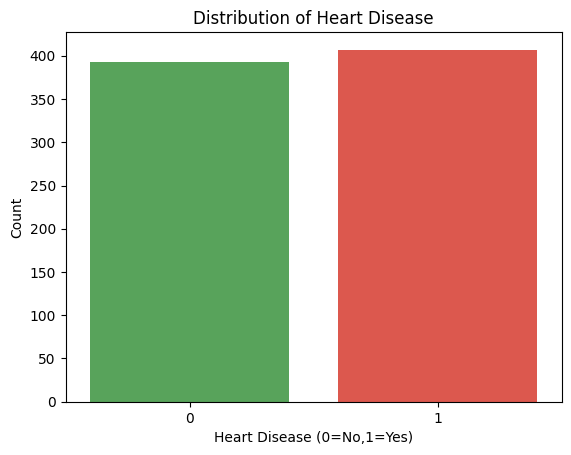

In [4]:
sns.countplot(x="heart_disease",data=df,palette=['#4CAF50', '#F44336'])
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0=No,1=Yes)")
plt.ylabel("Count")
plt.show()


### Interpretation:

The chart shows the distribution of patients with and without heart disease. The green bar represents patients without heart disease, while the red bar represents those with the condition.

We can observe that the red bar is slightly higher than the green bar, which means there are a few more patients with heart disease in this dataset. This indicates a slight class imbalance, but it is not very extreme.

Using different colors makes it easier to visually compare the two groups and quickly understand the distribution, which is important before building any model.

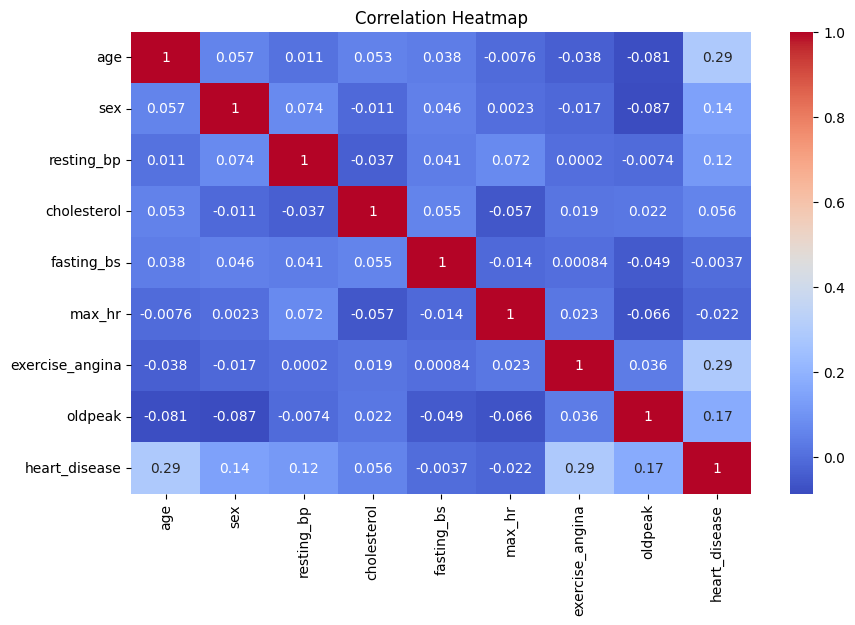

In [5]:

plt.figure(figsize=(10,6))

# Select only numeric columns to avoid errors
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Interpretation:

The correlation heatmap shows the relationship between different numerical features and the target variable `heart_disease`. Most of the variables have low to moderate correlation with each other, which indicates that there is no strong multicollinearity in the dataset.

Looking at the target variable, we can see that `age` and `exercise_angina` have the highest positive correlation (around 0.29) with heart disease. This suggests that older individuals and those experiencing exercise-induced angina are more likely to have heart disease.

The feature `oldpeak` also shows a moderate positive relationship (0.17), indicating it may play a role in predicting heart disease. On the other hand, features like `fasting_bs` and `max_hr` show very weak or near-zero correlation, meaning they may not be strong predictors individually.

Overall, no single feature has a very strong correlation with the target, which suggests that the model will need to consider multiple features together to make accurate predictions rather than relying on just one variable.

/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_48258/2986913462.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease',y='age',data=df,palette=['#4CAF50', '#F44336'])


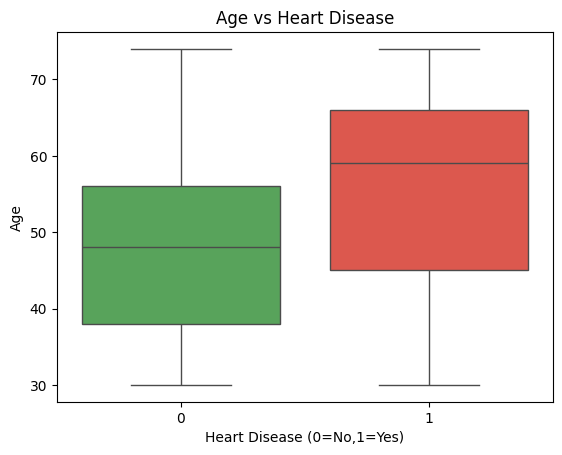

In [6]:
sns.boxplot(x='heart_disease',y='age',data=df,palette=['#4CAF50', '#F44336'])
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease (0=No,1=Yes)")
plt.ylabel("Age")
plt.show()

### Interpretation:

The boxplot compares the age distribution of patients with and without heart disease. We can see that patients with heart disease (1) generally have a higher median age compared to those without heart disease (0).

The spread of ages is also slightly wider for patients with heart disease, indicating more variation in that group. Additionally, the overall age range for both groups overlaps, which means age alone cannot fully determine whether a person has heart disease.

However, the higher median age in the heart disease group suggests that older individuals are more likely to be affected, making age an important feature for prediction when combined with other variables.

In [7]:
#Fill missing numerical values with median
df=df.fillna(df.median(numeric_only=True))

print(df.isnull().sum())


age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


### Interpretation:

After handling missing values using median imputation, we can see that all columns now have zero missing values. This confirms that the dataset is complete and ready for further processing.

Using the median helps ensure that the data distribution is not affected by extreme values, making it a reliable method for filling missing entries. Cleaning the data at this stage is important to avoid errors during model training and to improve the overall accuracy of the model.

In [8]:
#One-hot encoding for categorical variables
df=pd.get_dummies(df,drop_first=True)

#Separate features and target
X=df.drop('heart_disease',axis=1)
Y=df['heart_disease']

#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


# Convert scaled data into DataFrame
X_scaled_df=pd.DataFrame(X_scaled,columns=X.columns)

print("\nAfter scaling:")
print(X_scaled_df.head())

















After scaling:
        age       sex  resting_bp  cholesterol  fasting_bs    max_hr  \
0  1.229854 -1.408927    0.702830     3.000527   -0.550392  0.887081   
1  0.451896  0.709760    2.003076     1.258794    1.816886 -1.257462   
2 -0.637245  0.709760   -0.164001    -1.383161   -0.550392  1.512573   
3  1.541037  0.709760   -1.030832    -1.344021   -0.550392  0.038200   
4 -1.181815  0.709760    1.136245     0.495562   -0.550392 -0.587292   

   exercise_angina   oldpeak  chest_pain_type_atypical_angina  \
0        -0.646869 -0.585809                         2.190229   
1         1.545908  0.194526                        -0.456573   
2         1.545908 -0.808762                        -0.456573   
3        -0.646869  0.083050                        -0.456573   
4        -0.646869 -0.585809                        -0.456573   

   chest_pain_type_non_anginal  chest_pain_type_typical_angina  \
0                    -0.600453                       -0.294884   
1                     1.6654

### Interpretation:

After applying feature scaling, all the numerical values are now standardized, meaning they are centered around 0 with a similar range. This is why we see both positive and negative values in the output.

Scaling ensures that all features contribute equally to the model and prevents variables with larger values (like cholesterol or resting_bp) from dominating the model’s learning process.

Additionally, categorical variables that were converted using one-hot encoding are also scaled, which helps maintain consistency across all features. This step improves the performance of machine learning models, especially those that are sensitive to the scale of data.

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,Y,test_size=0.2,stratify=Y,random_state=42)
# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

# Convert to DataFrame for viewing
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)



X_train shape: (640, 15)
X_test shape: (160, 15)
Y_train shape: (640,)
Y_test shape: (160,)


### Interpretation:

The dataset has been successfully split into training and testing sets. Out of the total data, 640 observations are used for training the model, while 160 observations are reserved for testing.

This follows the standard 80:20 split, where most of the data is used to train the model and a smaller portion is used to evaluate its performance on unseen data.

Additionally, the feature sets (X_train and X_test) contain 15 variables, while the target sets (y_train and y_test) contain the corresponding labels. This confirms that the data has been properly prepared for model training and evaluation.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train models
dt.fit(X_train, Y_train)
rf.fit(X_train, Y_train)
gb.fit(X_train, Y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

# Store models in dictionary for easy comparison
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

# Evaluate each model
for name, model in models.items():
    print(f"\n{name}")

    # Make predictions
    Y_pred = model.predict(X_test)

    # Print confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, Y_pred))

    # Print precision, recall, f1-score
    print("\nClassification Report:")
    print(classification_report(Y_test, Y_pred))




Decision Tree
Confusion Matrix:
[[56 23]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Random Forest
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
     

### Model Evaluation and Comparison:

The performance of three models — Decision Tree, Random Forest, and Gradient Boosting — was evaluated using confusion matrix, precision, recall, and F1-score.

The Decision Tree model achieved an accuracy of 70%, with balanced precision and recall around 0.70. However, it made relatively more incorrect predictions compared to the other models, indicating possible overfitting and lower generalization ability.

The Random Forest model performed the best among all three models, achieving an accuracy of 79%. It shows strong performance across both classes, with precision and recall values close to 0.80. The F1-score is also highest (around 0.79–0.80), indicating a good balance between precision and recall. Additionally, it has fewer misclassifications in the confusion matrix compared to the other models.

The Gradient Boosting model also performed well with an accuracy of 77%, slightly lower than Random Forest. Its precision, recall, and F1-score are consistent (around 0.77), but it still has slightly more errors compared to Random Forest.

Overall, Random Forest is the best-performing model because it achieves the highest accuracy and F1-score, while also maintaining a good balance between precision and recall. This makes it more reliable for predicting heart disease compared to the other models.

In [12]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

# Apply GridSearchCV
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

# Train grid search
grid.fit(X_train, Y_train)

# Best parameters found
print("Best Parameters:", grid.best_params_)

# Get best model
best_model = grid.best_estimator_

# Predict using tuned model
Y_pred = best_model.predict(X_test)

# Evaluate tuned model
print("\nTuned Model Performance:")
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))



Best Parameters: {'max_depth': 5, 'n_estimators': 100}

Tuned Model Performance:
Confusion Matrix:
[[58 21]
 [16 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Hyperparameter Tuning Interpretation:

Hyperparameter tuning was performed using GridSearchCV to improve the performance of the Random Forest model. The best parameters obtained were max_depth = 5 and n_estimators = 100, which control the complexity and number of trees in the model.

After tuning, the model achieved an accuracy of 77%, which is slightly lower than the earlier Random Forest model (79%). However, the precision, recall, and F1-score remain well balanced, all around 0.76 to 0.78.

The confusion matrix shows that the model is still performing reasonably well, correctly identifying most cases of both classes, with fewer extreme errors.

Although the tuned model did not outperform the baseline Random Forest in terms of accuracy, it provides a more controlled and less complex model, which can help reduce overfitting and improve generalization.

Overall, hyperparameter tuning helped optimize the model, but in this case, the original Random Forest model still performs slightly better.